In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sinter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from qecsim.xzzx_code.circuit import XZZX_code
from qecsim.threshold_num.calc_threshold import threshold_approx
import pickle
import numpy as np

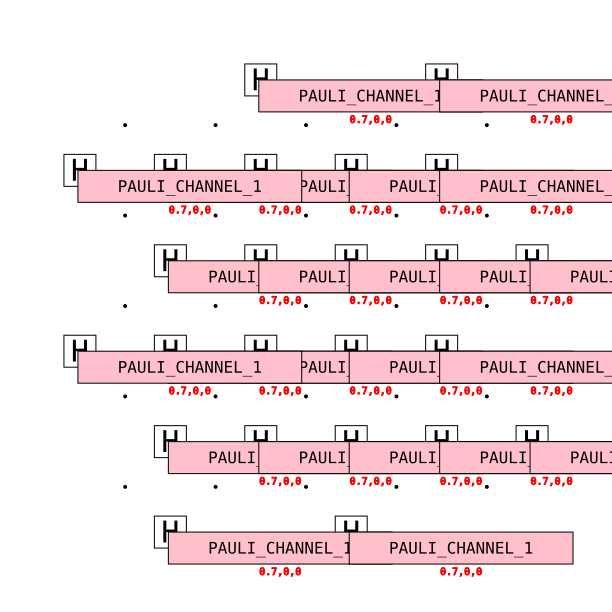

In [30]:
XZZX_code(distance = 5, rounds = 5, state_init = "Hor", noise_bias = [1,0,0], after_c_pauli_channel_prob = 0.7).diagram("timeslice-svg", tick = 1)

In [ ]:
# Initlize Saving Array
num_value : list = []

# Changing Bias setting
for b_x in np.arange(0.0, 1.2, 0.2):
    for b_y in np.arange(0.0, 1.2, 0.2): 
        for b_z in np.arange(0.0, 1.2, 0.2):

            #Creating Current Bias
            current_bias = [b_x,b_y,b_z]

            if current_bias == [0,0,0]:
                continue

            # Running simulation
            task_noisy_v = [sinter.Task(
                circuit = XZZX_code(
                    distance = d,
                    rounds = d, 
                    state_init ="Ver",
                    noise_bias = current_bias,
                    after_c_pauli_channel_prob = noise
                    ),
                json_metadata={'p': noise, 'distance' : d, 'bias' : current_bias}
                ) 
                for noise in [0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.150, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
                for d in [7, 9]
                ]


            stats_noisy_v : list[sinter.TaskStats] = sinter.collect(
                num_workers = os.cpu_count(),
                tasks=task_noisy_v,
                decoders=['pymatching'],
                max_shots=100_000_0,
                max_errors=10000,
                print_progress=True
            )

            # calculate threshold and save -> If Error skip and set 0 
            try:
                calc_th = threshold_approx(stats_noisy_v)
                num_value.append([current_bias,calc_th])

            except Exception:
                num_value.append([current_bias,0])

# Convert into array
num_value_array = np.array(num_value)


In [3]:
# Convert to 2-column array: [bias (flattened), p_c]
array = np.array([[bx, by, bz, pc] for [ [bx, by, bz], pc ] in num_value])

NameError: name 'num_value' is not defined

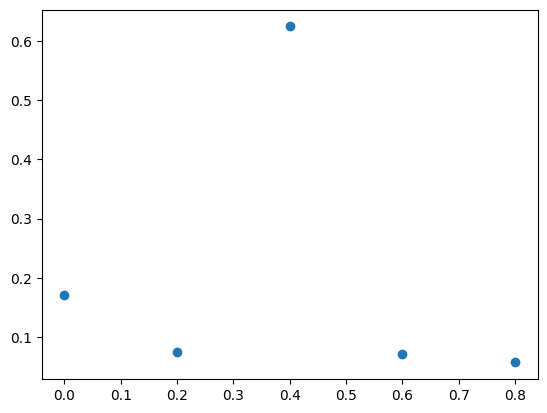

In [ ]:
x_values = array[:,2]
y_values = array[:,3]

plt.scatter(x_values, y_values)